## Vinho Verde Wine Quality Analysis Notebook

___

### Notebook by: [Sofia French](https://www.ncl.ac.uk/learning-and-teaching/digital-technologies/nula/guidance-and-support/find-my-students/)
### Student Number: `230057999`

## Table of contents
___
#### 1. [Introduction](#1-introduction)
#### 2. [The Problem Domain](#2-the-problem-domain)
#### 3. [The Datasets at a Glance](#3-the-datasets-at-a-glance)
#### 4. [Task 1: Exploratory Analysis](#4-task-1-exploratory-analysis)
#### 5. [Task 2: Variable Analysis](#5-task-2-variable-analysis)
#### 6. [Task 3: Modelling](#6-task-3-modelling)
#### 7. [Task 4: Model Evaluation](#7-task-4-model-evaluation)
#### 8. [Extensions Overview](#8-extensions-overview)
#### 9. [Conclusion](#9-conclusion)
#### 10. [References](#10-references)

## Introduction

___

This notebook was developed for my  **Data Science** project (*2034*) assigned in Stage 2 of my degree at Newcastle University. It follows the task description highlighted on [Canvas](#https://ncl.instructure.com/courses/54995/pages/task-description-for-data-science?module_item_id=3344525) and draws inspiration from public resource notebooks, such as [Randal S. Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) and all published under the [data_visulisation](#https://github.com/EllyOK/data_visulisation/tree/main/csc2034-ds-demos-master) GitHub repository. Specifically, following the structure of these notebooks has helped me effectively tell my *"data science story"* in a readable and consistant way.

As submission files were decided independently, to demonstrate the work I've completed I've chosen to include most of my GitHub repository, **excluding**: a latex/ dir, it's helper bin/ dir, and my Makefile**. 

The latex/ (and bin/) directories contain drafts of task findings for my final report, and as `make` is not automatically installed on all machines (e.g. Windows) and thus has been excluded.

A brief overview of my file structure has been attatched in the root README and pre-generated docs have been included where necessary as a precaution, but can be overwritten.


## The Problem Domain
___

As outlined in the provided task description, I have been *"hired to consult for a winery in Portugal"* who wish to understand the truth behind the **quality disparity** in their **Vinho-Verde** wines.

Provided are three datasets, 

```
• winequality-red.csv
• winequality-white.csv
• winequality.names
```

The two `.csv` files include large data for red and white wines, and each contains data points with a set of 12 variables; 11 of which are physicochemical, with the last being the perceived quality rating.

My task is to create *"one or more models to predict quality given all other variables"*, in order for the winery to determine which properties of their wine are most influential to quality.

## The Datasets at a Glance
___

### Answering Olson's Questions 

[Randal S. Olson](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) mentioned in his notebook, *"the first step to any data analysis project is to define the question or problem we're looking to solve, and to define a measure (or set of measures) for our success at solving that task"*. With that in mind, I examined the project and it's requirements using [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) questions:


> **Did you specify the type of data analytic question?**

I'm trying to predict the quality of Vinho Verde wines based on 11 properties, e.g. `acidity`, `sugar`, and `alcohol content`.
This is both an exploratory and predictive modelling problem. 
First, I'll need to explore and visualise how these features relate to a wines perceived quality, then I can build models to classify and regress the quality based on the most influential features.

> **Did you define the metric for success before beginning?**

It differs based on whether I'm using classification or regression, but both should use `k-fold cross validation`.

For *classification* models, the suggested metrics are:
1. F1-score
2. AUC
3. ROC

For *regression* models:
1. RMSE 
2. MAE
3. Related "error metrics"

> **Did you understand the context for the question and the scientific or business application?**

I'm consulting for a winery in Portugal who wish to understand which features of their wines most strongly determine quality.

This analysis will inform the winery on which properties of wine are the most and least influential to quality so they can adjust their wine production process in order to make higher quality wines (at least, I assume, it's proven difficult to get ahold of any stakeholders).

> **Did you record the experimental design?**

In both datasets, each record corresponds to a single wine. As told to in the project report, the two datasets are large and *"each data point is a set of 12 variables; 11 of these are physicochemical measures, and the last is the perceived quality (sensory output)"*. 

> **Did you consider whether the question could be answered with the available data?**

The dataset is well suited for determining factors that influence wine quality. However, there are **limitations**:
- Quality is subjective and differs on consumer basis
- There may be other factors that influence quality that are not recorded, like aging

### Exploring the Datasets

Before I begin with the required tasks, as suggested in [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook and hinted at in the [Canvas](https://ncl.instructure.com/courses/54995/pages/task-description-for-data-science?module_item_id=3344525), it's best to quickly check the data's sanity.  

Specifically, I'm checking for errors or unexpected qualities in either dataset. For this project, both datasets are well regarded and tested, meaning it is safe to assume the data is clean. However, for good practice, it can't hurt to double check.

To do this, I'll read both datasets into a pandas data frame (*df*) and display the first 5 records. First, the red wine dataset:

In [1]:
import pandas as pd

wine_red = pd.read_csv("../datasets/winequality-red.csv",sep=";")
wine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


As expected, the data is loaded and populated. Now for white wine: 

In [2]:
wine_white = pd.read_csv("../datasets/winequality-white.csv",sep=";")
wine_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Again, the dataset appears complete, with 12 fields and each as listed in the brief. No problems here.

Next, starting again with red wine, I'll use pandas `describe` to examine input data from two different key fields: `alcohol` and `residual sugar`.

In [3]:
wine_red[["alcohol", "residual sugar"]].describe()

,alcohol,residual sugar
count,1599.000000,1599.000000
mean,10.422983,2.538806
std,1.065668,1.409928
min,8.400000,0.900000
25%,9.500000,1.900000
50%,10.200000,2.200000
75%,11.100000,2.600000
max,14.900000,15.500000


Focusing first on `alcohol`:
- It has a good range, with the `min` value at `8.4` and `max` value at `14.9`.
- This makes it clear why later separating into a three valued variable `alcohol_cat`, with *low, mid, and high* values would be beneficial - there is sufficient spread to justify three levels.

Next on `residual sugar`:
- It appears most red wines are dry as the mean is approximately `3`.
- The data is skewed heavily to the right tail, as some outlier values have residual sugars as high as `15.5`.
- This makes it clear why a binary value splitting the sweetness evenly (`isSweet`) would be beneficial when examining this feature.

**Moving onto white wine**, I'll perform the same analysis.

In [4]:
wine_white[["alcohol", "residual sugar"]].describe()

,alcohol,residual sugar
count,4898.000000,4898.000000
mean,10.514267,6.391415
std,1.230621,5.072058
min,8.000000,0.600000
25%,9.500000,1.700000
50%,10.400000,5.200000
75%,11.400000,9.900000
max,14.200000,65.800000


Focusing first on `alcohol`:
- Very similar to red wine, however white wines have a slightly higher mean (`10.51...` vs. `10.42...`).
- Spread is also larger than red (stddev as `1.23...` vs. `1.07...`).
- But again, this is a well distributed variable and thus supports separating into a three valued `alcohol_cat` variable.

Next on `residual sugar`:
- Much higher mean than in the red wine dataset (mean = `6.39...` vs. `2.54...`).
- The max value (`65.8`) is an extreme outlier.
- Again, the distribution is very right tail heavy, though much more so than with the red wines.
- The mean (`6.39...`) again suggests many dry wines and a lower quantity of sweet wines.

#### First Conclusions

For both datasets:
- In the later analysis with the `alcohol_cat` category, it would make sense to split into three values as both datasets have good spread (between `min` and `max` valued.)
- In the later analysis with the `isSweet` category, it would make sense to split the data more evenly to avoid class imbalance: having a lack of high sweetness wines and a large amount of dry wines.

Since both datasets seem initially OK, I'll now create a data frame to contain them for later plotting and analysis, and store the colours and palettes for combined plots.

In [5]:
wine_red["type"] = "red"
wine_white["type"] = "white"
wine_all = pd.concat([wine_red, wine_white])

palette_red_white = {"red": "#d62728", "white": "#1f77b4"}

#### First Plots

Before I explore the two fields any further, in preparation for both initial and later plots, I'll import my chosen libraries: `matplotlib` and `seaborn`. 

Both were chosen over the other mentioned alternative, `Altair` for the same reasons:
1. Simpler
2. More tutorials
3. Widely used in example notebooks

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

# Set style
sb.set_theme(style="whitegrid", font_scale=1.2)
palette_red = sb.color_palette("Reds", n_colors=10)
palette_white = sb.color_palette("Blues", n_colors=10)

Next, I'll generate a scatterplot matrix for both datasets. 

This was suggested in [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook as a tool to quickly check for errors or anomalies.

Originally, I compared every category against `quality`, but the 121 generated scatterplots were too busy for me to gain any insight from!

Instead, for a quick initial look, I'll compare `alcohol`, `volatile acidity`, `sulphates` and `citric acid` against eachother. The shade of each point represents `quality` from a scale of 3-8.

For use in my task drafts, I'll save all generated figures for this project in the directory `figures/`. For more information on this, see [Introduction](#1-introduction).

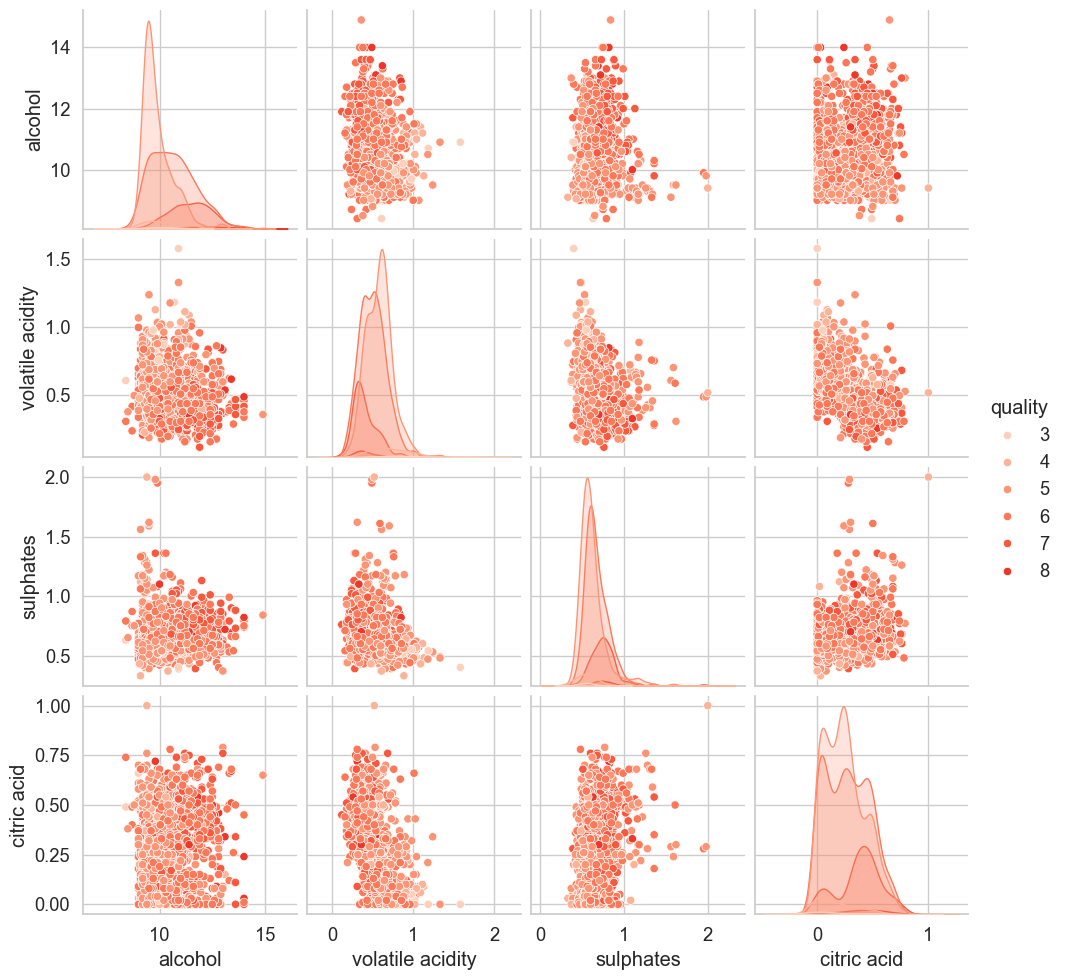

In [7]:
sb.pairplot(
    wine_red[["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]],
    hue="quality",
    palette=palette_red[1:7]
    )
plt.savefig("../figures/init_scatterplot_matrix_red")

#### Observations

A quick look at patterns in this plot suggests:

**For `Alcohol`**:
- In every plot (excluding `volatile acidity`) where `alcohol` is compared, higher quality wines tend to correlate to higher alcohol content.
- The KDE plot shows that low quality wines peak at **lower alcohol levels**, whereas high quality wines peak at **higher alcohol levels**.

**For `Volatile Acidity`**
- The trend is the opposite to `alcohol` - higher `volatile acidity` appears to correlate with lower quality wines.
- In the KDE, it seems wines with lower qualities cluster at higher values of `volatile acidity`.

**For `Sulphates`**
- There"s a slight pattern with high quality wines having slightly higher sulphates, but not strongly enough to apply causation.

**For `Citric Acid`**
- Hard to interpret — there’s no obvious relationship and dots are scattered.

#### First Plot Conclusions

- **Alcohol** appears to be strongly correlated with better quality wines, and is the most predictive feature out of the few I plotted and interpreted.
- **Volatile acidity** is negatively correlated with quality.
- **Sulphates** may be slightly positively correlated with quality.
- **Citric acid** may not be a strong predictor.

Now to examine the ***white wine dataset***:

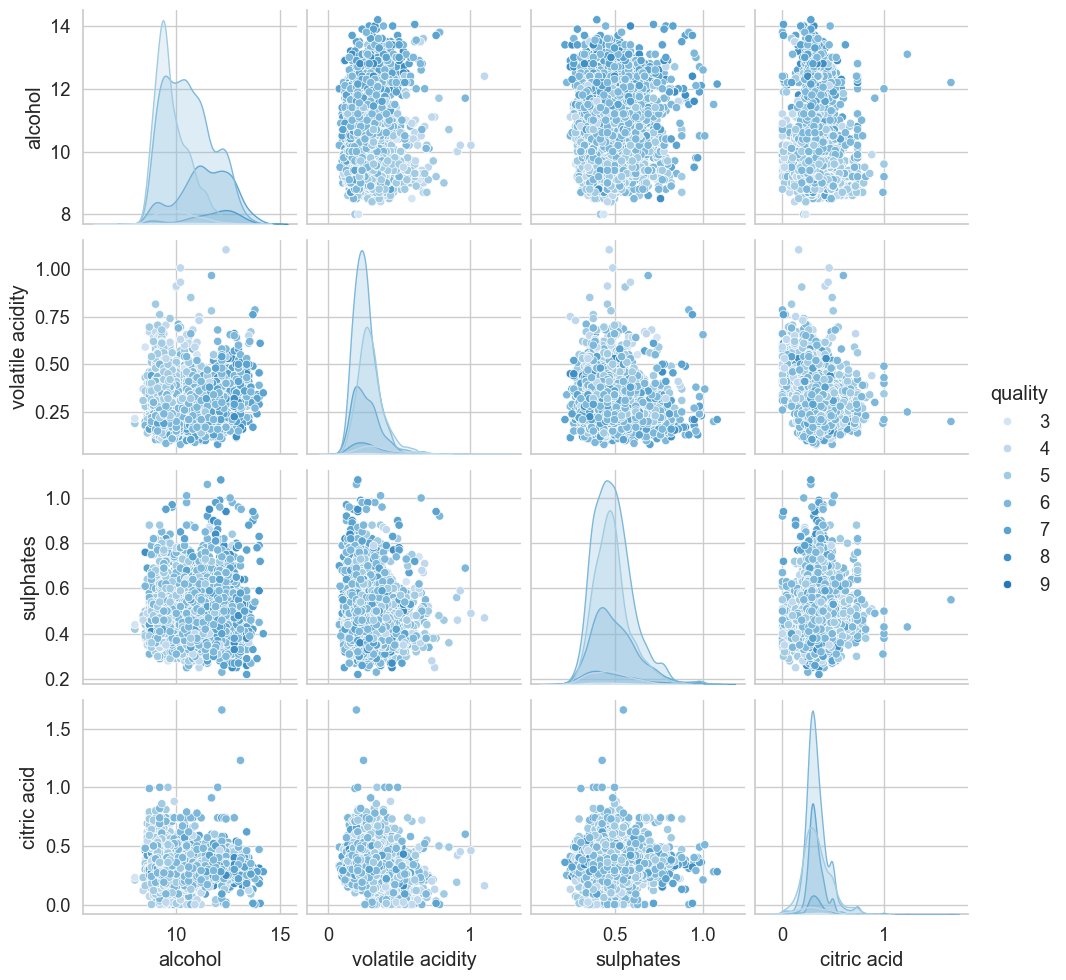

In [8]:
sb.pairplot(
    wine_white[["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]],
    hue="quality", 
    palette=palette_white[1:8]
    )
plt.savefig("../figures/init_scatterplot_matrix_white")

#### Observations

In the white wine scatterplot matrix:

**For `Alcohol`**:
- Just like in red wine: higher alcohol tends to mean higher quality.
- The KDE plot shows highest quality wines peak again around higher alcohol values.

**For `Volatile Acidity`**
- Less dramatic than in red wine, but trend keeps - higher volatile acidity tends to correlate with lower quality wines.
- In the KDE, low qualities are again concentrated at higher values.

**For `Sulphates`**
- Again, there's some correlation: high quality wines could be influenced by higher sulphates.
- KDE doesn't suggest much correlation.

**For `Citric Acid`**
- Similar to red: no obvious relationship with quality.
- KDE shows qualities are overlapping.

#### First Plot Conclusions

- **Alcohol** is a strong predictor of quality in both red and white wines, and may be a useful feature for later modelling.
- **Volatile acidity** is negatively correlated with quality, and again may be helpful later.
- **Sulphates** *could* have a slight positive relationship with quality.
- **Citric acid** is probably worth dropping in my later modelling.

### Data Integrity Assumption

[Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook has other steps before exploring his dataset, including **tidying** and **unit testing** the data. 

I have chosen to skip these steps for a few reasons:
- The red and white wine datasets used in this project are widely explored and arguably benchmark datasets with almost 200 results on [Kaggle](#https://www.kaggle.com/search?q=vinho+verde) appearing for the search "vinho verde". 
- The datasets were provided by the university.

And given the fact that they contain:
- No missing values
- No unusual records
- Contain the expected features

There is no need for extensive data cleaning or validation, though I will apply  stripping to each column to ensure consistency when referencing variables.

In [9]:
wine_red.columns = wine_red.columns.str.strip()
wine_white.columns = wine_white.columns.str.strip()

## Task 1: Exploratory Analysis

___

Now the data has been *loaded*, *checked*, *plotted* and *stripped*, it's time to move onto the required tasks. 

Briefly, for Task 1, the requirements are:

(a) Plot and compare the distribution of wine `quality` for red and white wines.

(b) Create a 3 level `alcohol_cat` variable (low, mid, high) based on `mean` +- `stddev`.

(c) Analyse and plot wine quality distribution by `alcohol` to assess its impact on quality.

(d) Create a binary `isSweet` variable by choosing a `residual sugar` threshold that balances the classes.

(e) Compare wine quality distributions for sweet vs dry wines to see if sweetness affects perceived quality.

### Task 1A: Wine Quality Distribution

To begin, I'll start with Task 1A: plotting and comparing how wine quality differs between red and white wines. 

For this task, I'll first use a box plot, as `quality` is discrete, and then a violin plot to examine the effect  of class distributions.

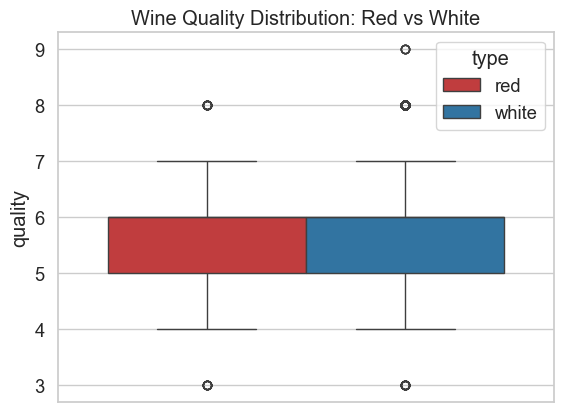

In [10]:
sb.boxplot(
    hue="type", 
    y="quality", 
    data=wine_all, 
    palette=palette_red_white
    )
plt.title("Task 1A")
plt.savefig("../figures/task1a_box_both")
plt.show()

#### Box Plot Observations

In the box plot above, for red and white wines:

| **Statistic**         | **Red Wine** | **White Wine** |
| :---------------- | :------: | :--------: |
| Median            |   5-6    |    5-6     |
| IQR               |   5-6    |    5-6     |
| Range             |   4-7    |    4-7     |
| Outliers          |   3,8    |   3,8,9    |

The plot shows:
- Central tendency is the same — both reds and whites cluster around a median of `5-6`.
- Spread is nearly identical — the IQR is the same for both.
- White wines show a slightly longer upper tail — suggesting highest quality wines are more common in white wines than reds.

#### Box Plot Conclusion

White and red wines have very similar quality distributions, but white wines may have a slightly higher upper potential for quality.

#### Violin Plot

Now lets plot the same data but this time using a **violin plot**.

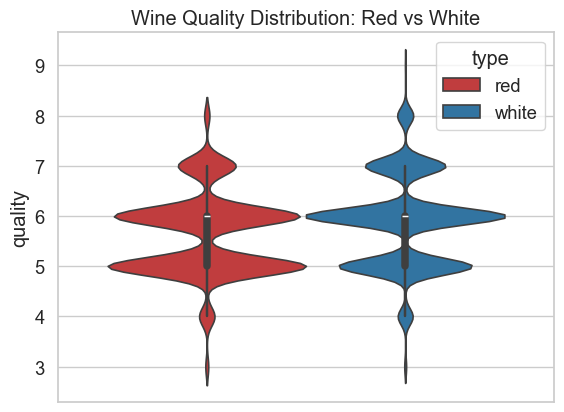

In [11]:
sb.violinplot(
    hue="type",
    y="quality",
    data=wine_all,
    palette=palette_red_white,
    inner="box",
    linewidth=1.2
)

plt.title("Wine Quality Distribution: Red vs White")
plt.savefig("../figures/task1a_violin_both")
plt.show()

#### Violin Plot Observations

The plot shows:
- The mode for *both* datasets is `6`, with `5` and `6` quality densities being almost identical for red wines.
- White wines have more spread between `5` and `7`, and higher density at `7` and `8`.
- A tiny peak at `3` is visible for red wine, but not for white.
- White wine has a longer tail, confirming the highest quality wines are in the white wines and that red wines dataset doesn't contain any qualities higher than `8`.

#### Violin Plot Conclusion

White and red wines have very similar quality distributions, but white wines have a slightly larger distribution and longer tail, confirming it holds more records and higher quality wines.

### Task 1B: Discretise Alcohol Content

Next is Task 1B: *"discretise the alcohol content variables into low, mid, and high based on its distribution"*.

To complete this task, following the description, I need to create a three valued variable `alcohol_cat` that represents:

- **low** alcohol < (`mean` - `stddev`)
- (`mean` - `stddev`) < **mid** alcohol < (`mean` + `stddev`)
- **high** alcohol > (`mea`n + `stddev`)

In [12]:
def add_alcohol_category(df):
    mean = df["alcohol"].mean()
    stddev = df["alcohol"].std()
    
    def discretise(alcohol):
        if alcohol < mean - stddev:
            return "low"
        elif alcohol > mean + stddev:
            return "high"
        else:
            return "mid"
    
    return df.assign(alcohol_cat=df["alcohol"].apply(discretise))

Now to apply to the data frames, including the combined dataset.

In [13]:
wine_red = add_alcohol_category(wine_red)
wine_white = add_alcohol_category(wine_white)
wine_all = add_alcohol_category(wine_all)

### Task 1C: Discretise Alcohol Content

Now there is a discrete alcohol category, I can begin plotting.

Task1C states: *"describe the distribution of wine quality as in (1.A), but separately for low-, mid-, and high-alcohol content."*. 

As I am comparing the distribution of how alcohol affects wine quality, I should again draw box plots to compare and check peaks and mode with a violin plot.

I'll start again using box plots, with red wine first:

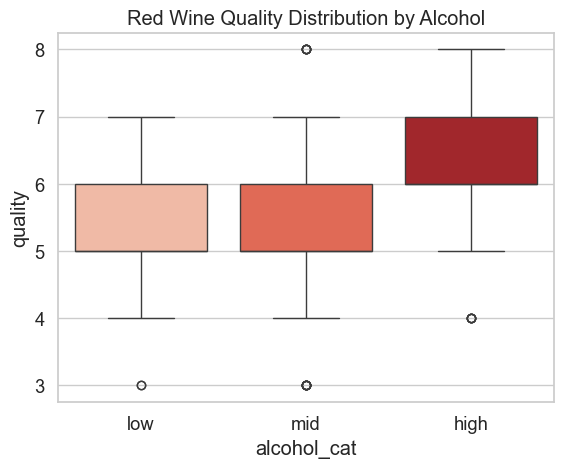

In [14]:
sb.boxplot(
    x="alcohol_cat", 
    hue="alcohol_cat",
    y="quality", 
    data=wine_red, 
    palette={
        "low": palette_red[2],
        "mid": palette_red[5],
        "high": palette_red[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )
plt.title("Task1C")
plt.savefig("../figures/task1c_box_red")
plt.show()

#### Box Plot Observations

In the box plot above, for **red wines**:

| **Statistic**     |   `low`    |   `mid`    |  `high`   |
| :---------------- | :------: | :------: | :------: |
| Median            |   5-6    |   5-6    |   6-7    |
| IQR               |   5-6    |   5-6    |   6-7    |
| Range             |   4-7    |   4-7    |   5-8    |
| Outliers          |    3     |   3,8    |    4     |


The boxplot for **red wine** quality by alcohol shows:
- Median quality increases for `high` alcohol wines.
- `low` and `mid` categories have very similar spread (IQR), but `high` alcohol wines have larger spread.
- Outliers at both small (3) and large (8) quality extremes are rare.

#### Box Plot Conclusion

Higher alcohol content in wines once again indicates strong positive correlation with quality.

Now to plot the same data but this time for ***white wine***:

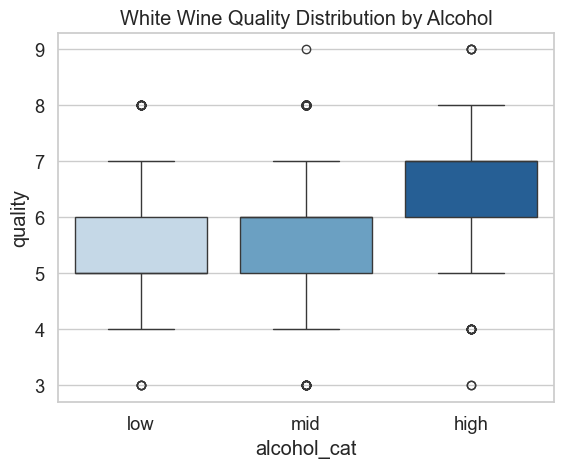

In [15]:
sb.boxplot(
    x="alcohol_cat", 
    hue="alcohol_cat", 
    y="quality", 
    data=wine_white, 
    palette= {
        "low": palette_white[2],
        "mid": palette_white[5],
        "high": palette_white[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )
plt.title("Task1C")
plt.savefig("../figures/task1c_box_white")
plt.show()

#### Box Plot Observations

Now, the box plot shows:

| **Statistic**     |   `low`    |   `mid`    |  `high`   |
| :---------------- | :------: | :------: | :------: |
| Median            |   5-6    |   5-6    |   6-7    |
| IQR               |   5-6    |   5-6    |   6-7    |
| Range             |   4-7    |   4-7    |   5-8    |
| Outliers          |   3,8    |  3,8,9   |  3,4,9   |


The boxplot for **white wine** quality is very similar to red wines':
- Median rises from at `high` alcohol levels.
- `high` alcohol levels have higher IQR (6–7) vs `low`/`mid` (5–6)
- More outliers overall, especially higher values (9 in `high`, 8 and 9 in `mid`)

#### Box Plot Conclusion

White wines also show a positive relationship between alcohol content and quality, maybe even more strongly than reds.

Now I'll plot both again, this time using violin plots. I'll start with red:

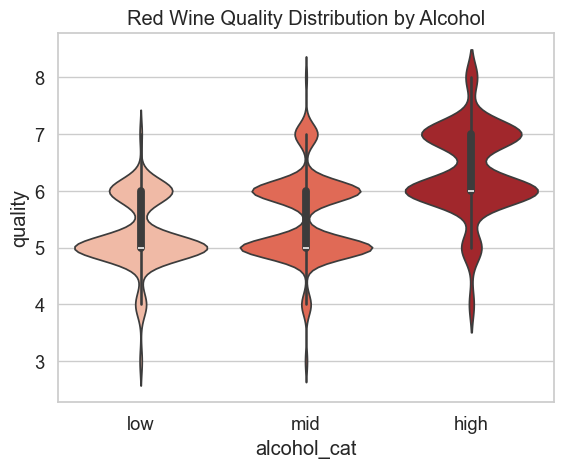

In [16]:
sb.violinplot(
    x="alcohol_cat", 
    hue="alcohol_cat", 
    y="quality", 
    data=wine_red, 
    palette= {
        "low": palette_red[2],
        "mid": palette_red[5],
        "high": palette_red[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )

plt.title("Task1C")
plt.savefig("../figures/task1c_violin_red")
plt.show()

#### Violin Plot Observations

For **red wines**:
- The density clusters confirm the box plot: peaks for `low` and `mid` are at quality 5–6, but for `high`, it's 6–7.
- `high` category has visibly thicker (thus more) higher quality wines.

#### Violin Plot Conclusion

The violin plot supports my analysis of the box plot — high alcohol levels in red wines correlate to higher quality ratings.

For the ***white wines***:

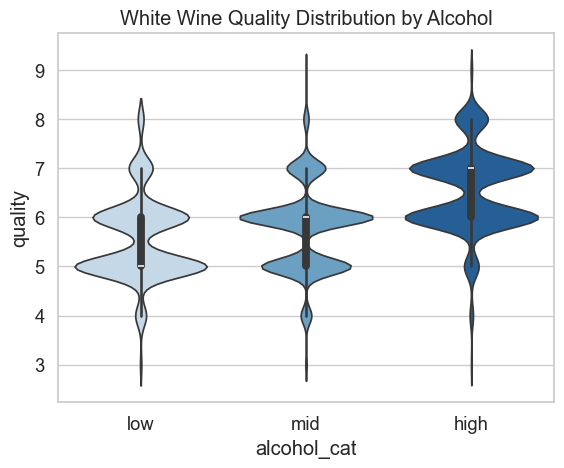

In [17]:
sb.violinplot(
    x="alcohol_cat",
    hue="alcohol_cat", 
    y="quality", 
    data=wine_white, 
    palette= {
        "low": palette_white[2],
        "mid": palette_white[5],
        "high": palette_white[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )

plt.title("Task1C")
plt.savefig("../figures/task1c_violin_white")
plt.show()

#### Violin Plot Observations

For **white wines**:
- The distribution is broader than red wine, but the same trend is visible - positive correlation between alcohol content and quality.
- `low` and `mid` cluster around `quality` 5–6
- `high` alcohol has a fatter top end, with more density at 7–8

#### Violin Plot Conclusion

In white wines, high alcohol again correlates with higher quality.


#### Task 1C: Conclusion

Both red and white wines show a clear positive association between alcohol content and quality. Wines in the high alcohol category consistently have higher medians, higher peaks, and more high end outliers.

**For Later Modelling** the consistant correlaton of alcohol content to quality suggests the alcohol feature could be **useful in both regression and classification modelling**.

### Task 1D

Now task 1C is complete, I"ll move onto task 1D - *"plot the residual sugar variable and identify a suitable threshold to separate 'sweet' from 'dry' wines"* using an *"isSweet"* binary variable.

#### `isSweet`

As seen in my earlier analysis, [Exploring the Dataset](#exploring-the-datasets), the distribution of residual sugar is **skewed** for both red and white wines. 

So, to examine it"s affect on quality, I"ll need to split the data evenly.

To do this, each record will be classified with an `isSweet` value of:

- `1`, if residual sugar >= median,
- `0`, if residual sugar < median.

Using the **median** means there should be an almost even split between sweet and dry records, providing **balanced classes**.

In [18]:
def add_isSweet(df):
    median = df["residual sugar"].median()
    return df.assign(isSweet=(df["residual sugar"] >= median).astype(int))

And now to apply to all data frames:

In [19]:
wine_all = add_isSweet(wine_all)
wine_red = add_isSweet(wine_red)
wine_white = add_isSweet(wine_white)

To double check: the task (*1D*) states: *"find a threshold such that each class has approximately the same number of records"*. 

The median should provide an even threshold, but to confirm:

In [3]:
isSweet_split = pd.DataFrame({
    "All Wines": wine_all["isSweet"].value_counts(normalise=True),
    "Red Wines": wine_red["isSweet"].value_counts(normalise=True),
    "White Wines": wine_white["isSweet"].value_counts(normalise=True),
})
isSweet_split.index = ["Dry (0)", "Sweet (1)"]
isSweet_split

NameError: name 'wine_all' is not defined

And it works - each data frame has been split approximately evenly. That"s **task 1D** complete!

### Task 1E: Plotting against `isSweet`

Now I"ll begin **task 1E**: *"repeat the distribution analysis"* of quality, this time with `quality` vs `isSweet`. 

Again, as I am comparing the *distribution* of how sweetness affects quality, I'll use box and violin plots.

For consistency, I"ll start with box plots and red wine first:

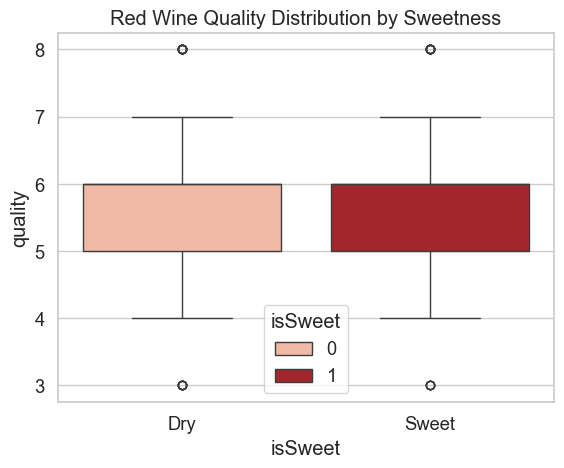

In [21]:
sb.boxplot(
    x="isSweet", 
    y="quality", 
    hue="isSweet",
    data=wine_red, 
    palette={
        0: palette_red[2],
        1: palette_red[8]
    },
)
plt.title("Task 1E")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1e_box_red")
plt.show()

#### Box Plot Observations

In the box plot above, for **red wines**:

| **Statistic**     |  `dry`   | `sweet`  |
| :---------------- | :------: | :------: |
| Median            |   5-6    |   5-6    |
| IQR               |   5-6    |   5-6    |
| Range             |   4-7    |   4-7    |
| Outliers          |   3,8    |   3,8    |


The boxplot for **red wine** quality by `isSweet` shows:
- Medians for dry and sweet wines are identical (5/6).
- IQR is also the same (5 to 6).
- Whiskers extend equally (4 to 7)
- Some rare outliers at 3 and 8 for both datasets.

#### Box Plot Conclusion

Sweet and dry red wines show no meaningful difference in quality. The distribution is visually identical, suggesting sweetness does not impact red wine quality in this dataset.

Now I"ll plot the same data but this time for ***white wine***:

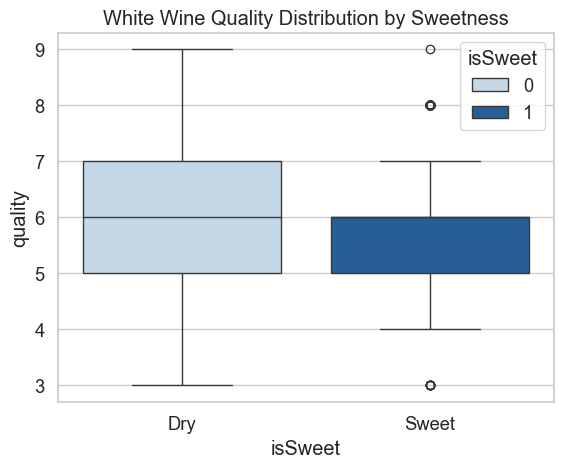

In [22]:
sb.boxplot(
    x="isSweet", 
    y="quality", 
    hue="isSweet",
    data=wine_white, 
    palette={
        0: palette_white[2],
        1: palette_white[8]
    },
)
plt.title("Task 1E")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1e_box_white")
plt.show()

#### Box Plot Observations

In the box plot above, for **white wines**:

| **Statistic**     |  `dry`   | `sweet`  |
| :---------------- | :------: | :------: |
| Median            |    6     |   5-6    |
| IQR               |   5-7    |   5-6    |
| Range             |   3-9    |   4-7    |
| Outliers          |    -     |  3,8,9   |


The boxplot for **white wine** quality by `isSweet` shows:
- Dry wines have a higher median.
- Dry wines also have a broader upper range, with qualities as high as 9.
- Sweet wines are more concentrated between 5–6, with fewer high qualities.

#### Box Plot Conclusions

Dry white wines are generally higher quality than sweet ones, but for reds the box plots suggest sweetness does not affect quality. 

Now to compare these findings against violin plots. 

Red wine first:

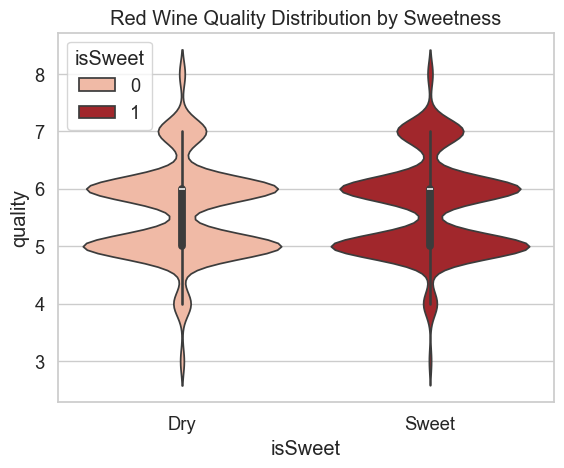

In [23]:
sb.violinplot(
    x="isSweet", 
    hue="isSweet", 
    y="quality", 
    data=wine_red, 
    palette= {
        0: palette_red[2],
        1: palette_red[8]
        },
    )

plt.title("Task 1E")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1e_violin_red")
plt.show()

#### Violin Plot Observations

In the plot above, for **red wines**:
- Distribution shapes for dry and sweet reds are nearly identical.
- Both groups show peaks at quality 5 and 6, with thinner tails at 4 and above 7.
- The median and spread are once again visually identical.

#### Violin Plot Conclusion

In red wines, sweetness has no clear effect on perceived quality. The violin plot confirms what the box plot showed — the distributions are hard to tell apart and almost the same.

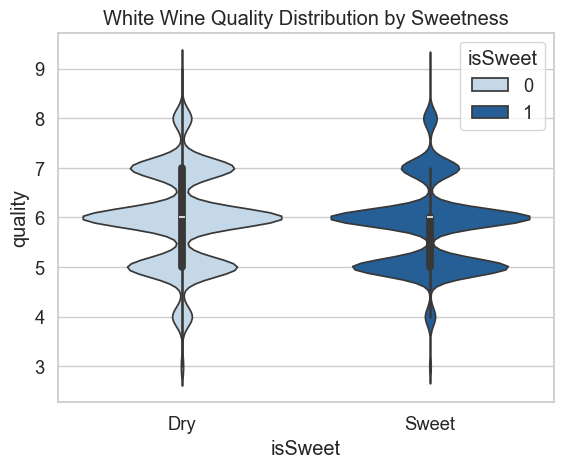

In [24]:
sb.violinplot(
    x="isSweet", 
    hue="isSweet", 
    y="quality", 
    data=wine_white, 
    palette= {
        0: palette_white[2],
        1: palette_white[8]
        },
    )

plt.title("Task 1E")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1e_violin_white")
plt.show()

#### Violin Plot Observations

For **white wines**:
- Dry white wines have a wider top half — more wines rated 7 and above.
- Sweet white wines are concentrated around quality 5–6, with fewer high quality wines.

#### Violin Plot Conclusion

In white wines, dry wines are more often rated higher than sweet ones. This violin plot makes the skew toward higher quality for dry whites and supports the previous box plot.

#### Task 1E Conclusion

The generated violin plots and box plots supported eachother, and suggested that white wine sweetness affects perceived quality, but red wine sweetness does not.

**For Later Modelling:** 
- The lack of correlaton of sweetness to quality suggests the `isSweet` feature would be **unhelpful in later models for red wine quality**
- The correlation between dry wines and higher quality could be a helpful predictor in **white wines quality** modelling.

## Task 2: Variable Analysis
___

For **task 2**, the description reads: *"try and determine which subset of your variables can be most useful for learning"*. 

To do this, it suggests:
- Analysing each pair of variables
- Analysing each variable and the quality outcome
- Producing a visual representation in the form of a Correlation Matrix

### Correlation Methods

Comparing the 3 suggested metrics, `pearson`, `kendall`, `spearman`:

| Method | Description | Use when |
|:------|:------|:------|
| **Pearson** | Measures linear correlations | Data is continuous and linear |
| **Spearman** | Measures monotonic correlation | Relationships may be non linear but ordered |
| **Kendall**  | Measures concordance between ranked pairs | Small datasets |

#### Justification for `Spearman`

In this project, I chose to use `spearman` correlation because:
- Wine quality is a **discrete variable** (measured from a scale of 1-10)
- Many features (e.g. alcohol, acidity) may have **non linear** but **monotonic** relationships with quality
- `spearman` handles these cases better than `pearson`, which assumes all relationships are linear
- The datasets are large, especially the white wine dataset, so `kendall` may not be as useful

Thus `spearman` is the most appropriate choice for the correlation analysis.

### Predictions:

Based on the previous analysis, I predict:
- Alcohol content will be a strong indicator of quality
- Volatile acidity content will be a negative indicator of quality
- Sweetness will be a strong indicator of quality for **white wines**

Below, I"ll define the correlation matrix first for each dataset:

In [25]:
spearman_cm_red = wine_red.corr(numeric_only=True, method="spearman")
spearman_cm_white = wine_white.corr(numeric_only=True, method="spearman")

Then, I'll plot the matrix for red wines:

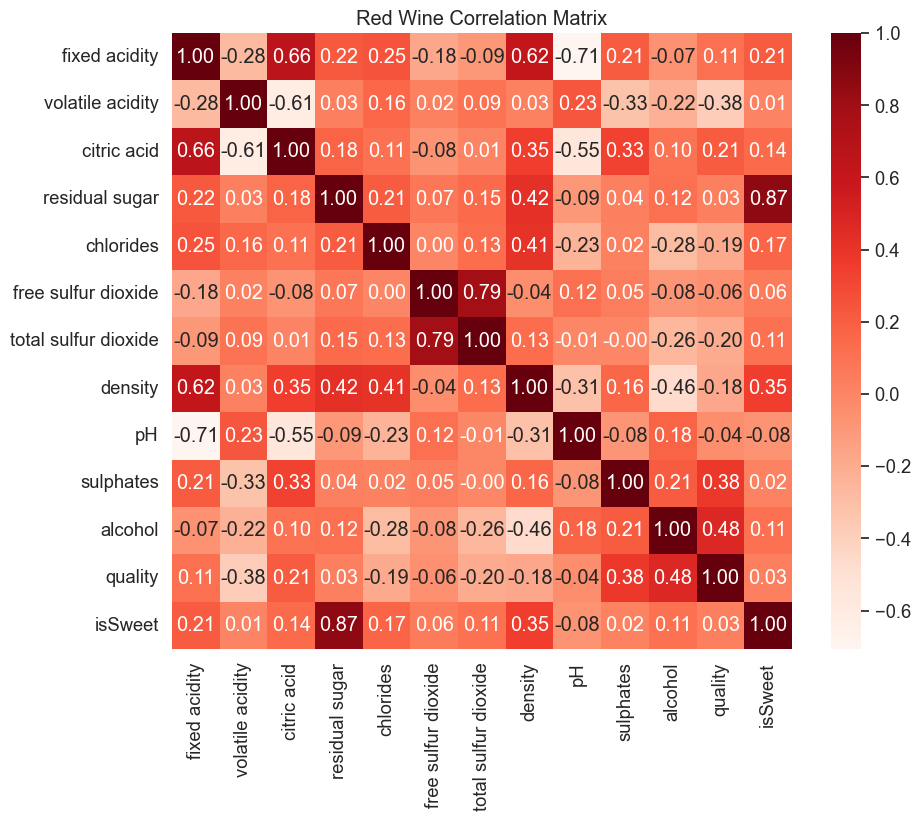

In [26]:
plt.figure(figsize=(10, 8))
sb.heatmap(spearman_cm_red, annot=True, cmap="Reds", fmt=".2f")
plt.title("Task 2")
plt.savefig("../figures/task2_red.png")
plt.show()

#### Red Wine Variable Correlations

For red wines, the most prominent relationships to quality are:

| Top Features      | Correlation with `quality` |
|:-----------------:|:--------------------------:|
| `alcohol`         |         **0.48**           |
| `sulphates`       |         **0.38**           |
| `volatile acidity`|        **-0.38**           |
| `citric acid`     |         **0.21**           |
| `total sulfur dioxide`   |        **-0.20**           |

##### Other Features:

- `alcohol` and `sulphates` are the most positively associated features with higher quality.
- `volatile acidity` shows a strong negative correlation — higher levels appear to reduce quality.
- `isSweet`, `pH`, `residual sugar`, and `free sulfur dioxide`, show very weak or negligible correlation and may be less useful.

Now I'll do the same for white wines:

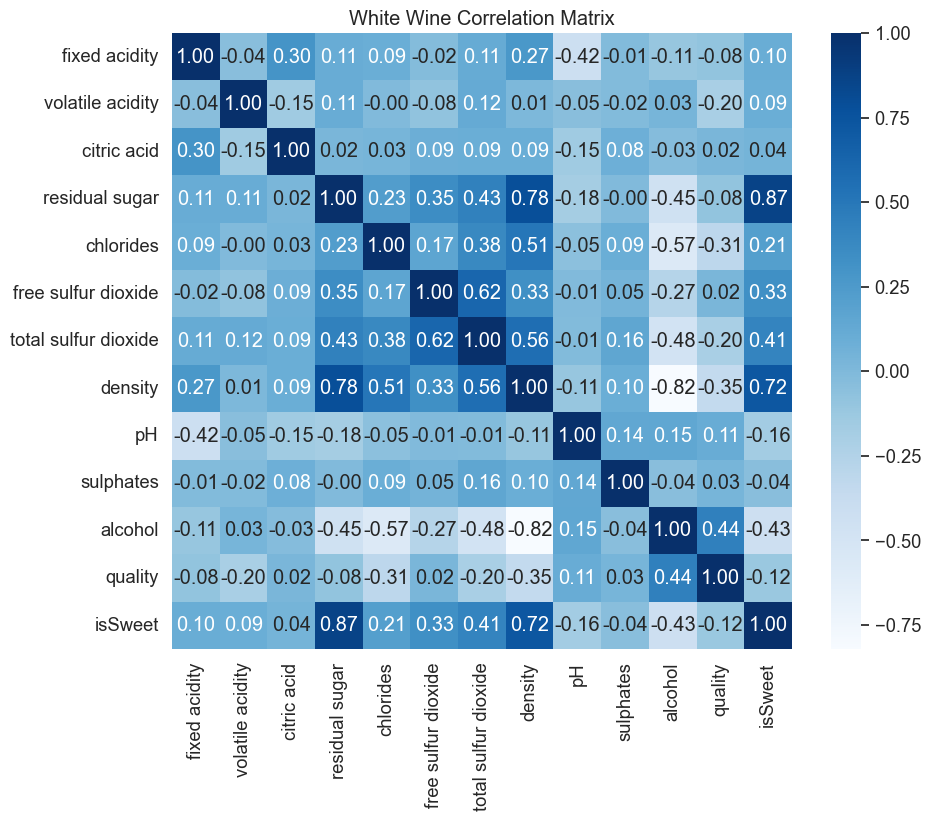

In [27]:
plt.figure(figsize=(10, 8))
sb.heatmap(spearman_cm_white, annot=True, cmap="Blues", fmt=".2f")
plt.title("Task 2")
plt.savefig("../figures/task2_white.png")
plt.show()

#### White Wine Variable Correlations

For white wine, the strongest relationships to quality are:

| Top Features      | Correlation with `quality` |
|:-----------------:|:--------------------------:|
| `alcohol`         |         **0.44**           |
| `density`         |        **-0.35**           |
| `chlorides`       |        **-0.31**           |
| `total sulfur dioxide`|        **-0.20**           |
| `volatile acidity`|        **-0.20**           |
| `isSweet`         |        **-0.12**           |
| `residual sugar`  |        **-0.08**           |

##### Other Features:

- `alcohol` is the most positively associated with higher quality.
- `density`, `chlorides`, `total sulfur dioxide` and `volatile acidity` show fair negative correlation — higher levels appear to reduce quality.
- `citric acid`, `free sulfur dioxide`, `sulfates` and `fixed acidity`, show very weak or negligible correlation for white wines and may be less useful for predicting quality.
- `isSweet` is a weak indicator of poor quality.

### Overall

Based on the correlation analysis for both red and white wines:

The **most helpful features** for predicting wine quality across both datasets are:
  - `alcohol` (strong positive correlation)
  - `sulphates` (only in red wine)
  - `density` and `chlorides` (negative correlation in white wine)
  - `volatile acidity` and `total sulfur dioxide` (negative correlations)

Features like `citric acid`, `residual sugar`, `free sulfur dioxide` (`isSweet` for reds) and `pH` show **weak or no correlation** and should be excluded from modelling.

Keeping features very highly correlated with eachother, like `density`/`isSweet` and `residual sugar`, or `free sulfur dioxide` and `total sulfur dioxide`, may be redundant.

### Final Feature Set for *Red Wine*

| Feature                | Correlation with `quality` | Why?                                      |
| :--------------------: | :------------------: | :----------------------------------------: |
| `alcohol`              |      **+0.48**       | Strongest positive predictor               |
| `sulphates`            |      **+0.38**       | Good positive predictor                    |
| `volatile acidity`     |      **−0.38**       | Strong negative predictor                  |
| `citric acid`          |      **+0.21**       | Mild positive                              |
| `density`              |      **+0.35**       | Could be useful, especially with `isSweet` |
| `total sulfur dioxide` |      **−0.20**       | Moderate negative                          |
| `isSweet`              |      **+0.11**       | Useful for binary classification           |


Dropping:
- `residual sugar`
- `free sulfur dioxide`
- `pH`




#### Final Feature Set for *White Wine*

| Feature                | Correlation with `quality` | Why?                                      |
| :--------------------: | :-----------------: | :----------------------------------------: |
| `alcohol`              |      **+0.44**      | Strongest predictor again                      |
| `density`              |      **−0.35**      | Strong inverse relationship                    |
| `chlorides`            |      **−0.31**      | Strongest mineral predictor                    |
| `total sulfur dioxide` |      **−0.20**      | Moderate negative                              |
| `volatile acidity`     |      **−0.20**      | Same as red wine                               |
| `isSweet`              |      **−0.12**      | Same as red wine                               |

Dropping:
- `residual sugar`
- `citric acid`
- `sulphates`
- `fixed acidity`
- `pH`

## Task 3: Modelling

___

Now I've explored the data and analysed relationships, I can begin modelling.

#### Approach

Task 3 is to *"experiment with one or more machine learning approaches that predict wine quality from the datasets variables"*.

I'll explore two different approaches; **binary classification** and **regression**. 

To do this, I'll split **task 3** into two different sections:

(A) **Binary classification**: Try and predict quality scores as **classes** based on a given threshold.
(B) **Regression**: Try and predict the **exact** quality score.


### Models

Initially, I'll use the `Random Forest` model for both binary classification and regression. This is the most popular model on Kaggle for this dataset and well documented. Since this is new territory, well-documented notebooks serve as great tutorials and comparing results will help me identify erroneous behaviour.

I will briefly explore other models alongside `Random Forest`, but will use RF as the primary baseline for comparisons.

Now, before I begin training, I"ll need to set up my data.

I'll start by dropping the features I don't want to use in training for the **red wine dataset** (including the "guessed" feature `quality`, styling feature `colour` and duplicate `alcohol_cat`).

In [28]:
X_red = wine_red.drop(columns=["quality", "type", "residual sugar", "isSweet", "free sulfur dioxide", "alcohol_cat", "pH"])
y_red = wine_red["quality"]

Next, I'll import `test_train_split` from `sklearn` and use it to divide my dataset into training and test data, using an 80/20 split:

In [30]:
from sklearn.model_selection import train_test_split

X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=1
)

### Task 3A: Binary Classification

Now I can begin binary classification.

First, I'll need to import and define my chosen classifier (`RandomForestClassifier`) fixing the randomness to make results reproducible.

In [31]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)

Next, I'll define the thresholds to test:

In [32]:
thresholds = [5, 6, 7]

Then, I'll import the relevant libraries for training.

For now, I won't use the recommended metrics in order to keep things simple. 

Instead, I will use the `accuracy_score` metric, (which calculates simply `number of correct predictions / number of true values`) to determine which threshold is best.

To store each thresholds' metric, I'll create an empty dict.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

accuracy_scores = {}

Now I'll use the **red wine data** and iterate through the thresholds. 

Each loop, I'll train my classifier 1000 times, storing the accuracy in my defined list above.

In [34]:
for threshold in thresholds:
    print("-" * 42)
    print(f"Train with threshold: `high quality > {threshold}`")

    y_red_bin = (y_red > threshold).astype(int)
    scores = []

    # TBR: Change back to 1000
    for _ in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_red, y_red_bin, test_size=0.2, stratify=y_red_bin
        )

        pipeline = Pipeline([
            ("classifier", rfc)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        scores.append(accuracy_score(y_test, y_pred))

    accuracy_scores[threshold] = scores

------------------------------------------
Train with Threshold: `quality > 5`
Repeating model training 1000 TBR times...


------------------------------------------
Train with Threshold: `quality > 6`
Repeating model training 1000 TBR times...
------------------------------------------
Train with Threshold: `quality > 7`
Repeating model training 1000 TBR times...


And check the mean of the results for each threshold:

In [35]:
print("| Threshold  | Accuracy (%) |")
print("|------------|--------------|")
for threshold in thresholds:
    scores = accuracy_scores[threshold]
    mean_accuracy = sum(scores) / len(scores)
    print(f"|'high' > {threshold:<2} | {mean_accuracy * 100:>10.2f}   |")

Average Threshold Accuracy (from 1000 runs)
------------------------------------------ 

| Threshold  | Accuracy (%) |
|------------|--------------|
|'high' > 5  |      81.47   |
|'high' > 6  |      91.00   |
|'high' > 7  |      98.97   |


These results show that **accuracy increases as the threshold increases**. However, this does **not** necessarily mean the model is improving.

As the threshold rises, fewer wines are labelled as "high quality", creating a **more imbalanced dataset**. When almost all wines belong to one class (e.g. most red wines have quality < 7 thus belong to `low`), the model can achieve high accuracy by simply predicting the `low` class.

This suggests that the classifier might be **biased**, especially at `threshold > 7`, where the accuracy is almost ***99%***. 

To verify this, I'll use these findings to plot accuracy distributions using a **histogram** and inspect class balances:

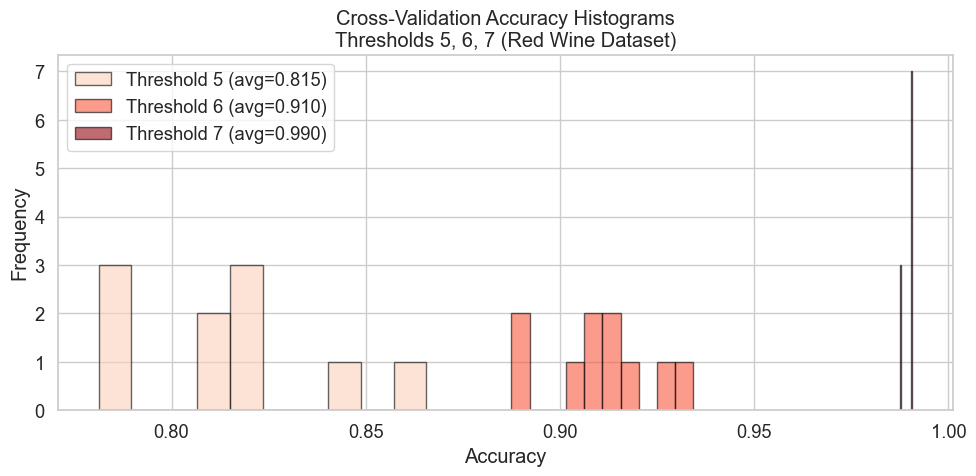

In [36]:
plt.figure(figsize=(10, 5))

for threshold in thresholds:
    scores = accuracy_scores[threshold]
    plt.hist(scores, bins=10, alpha=0.6, label=f"Threshold {threshold} (avg={np.mean(scores):.3f})",
             color=palette_red[1 if threshold == 5 else 5 if threshold == 6 else 9], edgecolor="black")

plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Task 3")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/task3_histogram_red.png")
plt.show()

Here, I can see for:

- Threshold 5: Accuracy ranges mostly from approximately 0.78–0.86.
- Threshold 6: Smaller range, from approximately 0.89–0.93.
- Threshold 7: Extreme — many scores very near to 1 (likely due to major class imbalance).

I can improve the model to avoid class imbalances. 

Right now, the model behaves slightly differently depending on which subset it trains on, with accuracy ranging from high 70's to high 90's.

To avoid this, I'll implement **cross validation**. I'll start by importing `cross_val_score` from `sklearn`. 

In [37]:
from sklearn.model_selection import cross_val_score

And I'll make an empty dict to again store the scores:

In [38]:
cv_scores_by_threshold = {}

And finally apply 10 fold cross validation to each threshold:

In [39]:
for threshold in thresholds:
    y_red_bin = (y_red > threshold).astype(int)
    scores = cross_val_score(rfc, X_red, y_red_bin, cv=10)
    cv_scores_by_threshold[threshold] = scores

Now, to check for any difference, I'll plot again as a histogram:

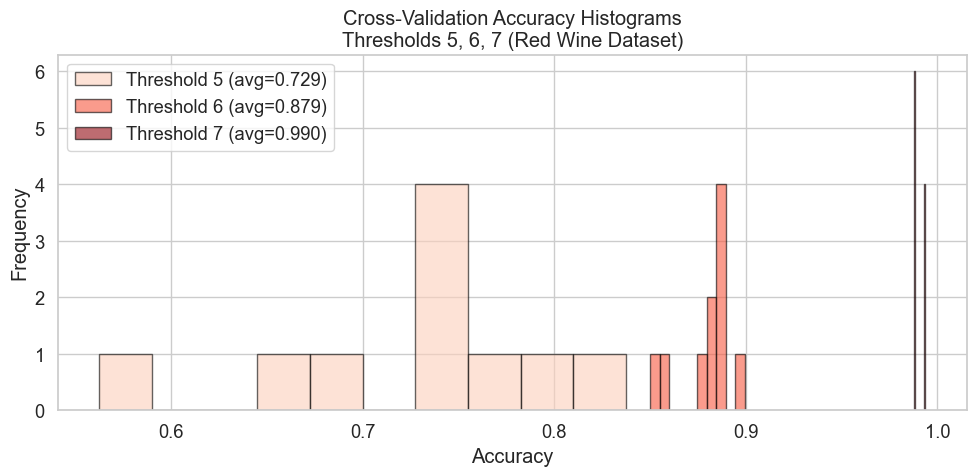

In [40]:
plt.figure(figsize=(10, 5))

for threshold in thresholds:
    scores = cv_scores_by_threshold[threshold]
    plt.hist(scores, bins=10, alpha=0.6, label=f"Threshold {threshold} (avg={np.mean(scores):.3f})",
             color=palette_red[1 if threshold == 5 else 5 if threshold == 6 else 9], edgecolor="black")

plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Task 3 CV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/task3_histogram_cv_red.png")
plt.show()

Now I can see:

- Threshold 5: Wide spread again, but a little smoother. Average ~0.807

- Threshold 6: Looks tighter than threshold 5; average ~0.908

- Threshold 7: Nearly perfect accuracy again — probably very few positive cases, so the model might learn to predict all as “low quality”.

To check whether threshold 7 is truly learning, I'll use the `sklearn` `classification_report`.

First, I'll again train the model, this time **only** on threshold 7:

In [41]:
y_red_bin_7 = (y_red > 7).astype(int)
X_train, X_test, y_train, y_test7 = train_test_split(X_red, y_red_bin_7, test_size=0.2, stratify=y_red_bin_7, random_state=42)

rfc.fit(X_train, y_train)
y_pred7 = rfc.predict(X_test)

Now I'll have a look at how many times it compares low vs high:

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test7, y_pred7, target_names=["Low", "High"], zero_division=0))

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99       395
        High       1.00      0.20      0.33         5

    accuracy                           0.99       400
   macro avg       0.99      0.60      0.66       400
weighted avg       0.99      0.99      0.99       400



Looking at the report for threshold 7, it’s clear that the model still strongly favours predicting “Low” (class 0), though it does make some predictions for “High” (class 1).

This is evident from:

- Precision for High = 1.00 -> when the model does predict class 1, it's correct.

- Recall for High = 0.20 -> it only identifies 1 out of the 5 actual high quality wines.

- F1-score for High = 0.33 -> reflects a very imbalanced performance.

So, the model performs poorly at finding high quality wines. This is likely due to class imbalance, where the minority class (high quality) has too few examples to learn from. The overall accuracy of 0.99 is therefore misleading — it mostly reflects correct predictions for the majority class.

I’ll compare this to threshold 5, where the class distribution is more balanced and the model may achieve a better trade-off between detecting both classes.

In [43]:
y_red_bin_5 = (y_red > 5).astype(int)
X_train, X_test, y_train, y_test5 = train_test_split(X_red, y_red_bin_5, test_size=0.2, stratify=y_red_bin_5, random_state=42)

rfc.fit(X_train, y_train)
y_pred5 = rfc.predict(X_test)

And then look at the report:

In [44]:
print(classification_report(y_test5, y_pred5, target_names=["Low", "High"], zero_division=0))

              precision    recall  f1-score   support

         Low       0.79      0.79      0.79       186
        High       0.82      0.81      0.81       214

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



At threshold 5, the model achieves a balanced and fair performance, with an overall accuracy of 0.80 and strong, symmetric metrics across both classes:

- Precision (Low/High): 0.79 / 0.82
- Recall (Low/High): 0.79 / 0.81
- F1-score (Low/High): 0.79 / 0.81

This is very different from the performance at threshold 7, where the model achieved superficially high accuracy (0.99) by largely ignoring the minority class. Here, the class distribution is more balanced, allowing the model to generalise better across both classes — making threshold 5 a much better choice for binary classification than 7, but it had lower performance than 6, so I'll look at that next.

In [45]:
y_red_bin_6 = (y_red > 6).astype(int)
X_train, X_test, y_train, y_test6 = train_test_split(X_red, y_red_bin_6, test_size=0.2, stratify=y_red_bin_6, random_state=42)

rfc.fit(X_train, y_train)
y_pred6 = rfc.predict(X_test)

Now to view 6's classification report:

In [46]:
print(classification_report(y_test6, y_pred6, target_names=["Low", "High"], zero_division=0))

              precision    recall  f1-score   support

         Low       0.94      0.99      0.96       346
        High       0.87      0.61      0.72        54

    accuracy                           0.94       400
   macro avg       0.91      0.80      0.84       400
weighted avg       0.93      0.94      0.93       400



With threshold 6, the model reaches a strong overall accuracy of 0.94, while still maintaining meaningful performance on the minority class:

- Precision (Low/High): 0.94 / 0.87
- Recall (Low/High): 0.99 / 0.61
- F1-score (Low/High): 0.96 / 0.72

Compared to threshold 5 (accuracy = 0.80, balanced but lower precision/recall), threshold 6 provides a better trade-off: it preserves the model's ability to detect high quality wines without sacrificing much performance on the dominant “Low” class. Unlike threshold 7 — where the model nearly ignored class 1 and produced misleading accuracy — threshold 6 shows the most balanced and effective performance overall, with a strong F1-score for both classes.

This suggests threshold 6 is the most appropriate boundary for binary classification in this task, and it's what I'll use going forward.

Now I've seen how Random Forest performs with different thresholds and chosen the most suitable one, 6,, I'll define some more models to try perform the same binary classification.

For new models, I'm going to scale my data. To do so, I'll first redefine my test and training data as so:

In [47]:
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red, y_red_bin_6, test_size=0.2, stratify=y_red_bin_6, random_state=42)

Then I'll scale based on that:

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_red_scaled = scaler.fit_transform(X_train)
X_test_red_scaled = scaler.transform(X_test)

Logical Regression model:

In [78]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight="balanced",)

Support Vector Match model:

In [77]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', probability=True, random_state=42, class_weight="balanced")

And Gradiant Boosting Classification model:

In [76]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)

To compare comdels, I'll define another dict to hold scores:

In [ ]:
evaluation_results ={}

And a helper function to evaluate each model going forward. This will stores the models scores and display them with a classification report and the average accuracy after applying 10 fold cross validation.

In [106]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='f1')
    print(f"{name} – 10-Fold CV F1-score: {scores.mean():.3f} ± {scores.std():.3f}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, target_names=["Low", "High"], output_dict=True)
    evaluation_results[name] = {
        "F1 High": report["High"]["f1-score"],
        "F1 Low": report["Low"]["f1-score"],
        "Accuracy": report["accuracy"],
        "CV F1": scores.mean()
    }

    print(classification_report(y_test, y_pred, target_names=["Low", "High"]))

Now to compare how these perform compared to my Random Forest model. 

I'll start with Logistic Regression:

In [107]:
evaluate_model(logreg,X_train_red_scaled, X_test_red_scaled, y_red_train, y_red_test, "LogReg")

LogReg – 10-Fold CV F1-score: 0.493 ± 0.065
              precision    recall  f1-score   support

         Low       0.96      0.80      0.87       346
        High       0.38      0.78      0.51        54

    accuracy                           0.80       400
   macro avg       0.67      0.79      0.69       400
weighted avg       0.88      0.80      0.82       400



### Logistic Regression – Threshold 6 Evaluation

- **10-Fold CV F1 (mean +- std)**: 0.493 ± 0.065  
- **F1-score (High)**: 0.51  
- **Accuracy**: 0.80  

Despite decent recall, low precision harms the F1. This confirms logistic regression underperforms Random Forest in this task.

Next, SVC:


In [108]:
evaluate_model(svc, X_train_red_scaled, X_test_red_scaled, y_red_train, y_red_test, "SVC")

SVC – 10-Fold CV F1-score: 0.527 ± 0.025
              precision    recall  f1-score   support

         Low       0.96      0.83      0.89       346
        High       0.42      0.78      0.54        54

    accuracy                           0.82       400
   macro avg       0.69      0.80      0.72       400
weighted avg       0.89      0.82      0.84       400



### SVC – Threshold 6

- **10-Fold CV F1**: 0.527 +- 0.025  
- **F1-score (High)**: 0.54  
- **Accuracy**: 0.82  

SVC slightly outperforms logistic regression on the minority class, with improved balance, but still falls short of Random Forest.

Now, Gradiant Boosting:


In [109]:
evaluate_model(gb, X_train_red_scaled, X_test_red_scaled, y_red_train, y_red_test, "GB")

GB – 10-Fold CV F1-score: 0.452 ± 0.131
              precision    recall  f1-score   support

         Low       0.92      0.97      0.95       346
        High       0.71      0.46      0.56        54

    accuracy                           0.90       400
   macro avg       0.82      0.72      0.75       400
weighted avg       0.89      0.90      0.89       400



### Gradient Boosting – Threshold 6

- **10-Fold CV F1**: 0.452 ± 0.131  
- **F1-score (High)**: 0.56  
- **Accuracy**: 0.90  

GB has good performance, especially in recall, but suffers from inconsistent precision across folds (high variance in CV). Still underperforms Random Forest.

Lastly, to really compare to Random Forest, I'll have to fine tune some parameters so the model doesn't use an **imbalanced class** or **over or underfit** any data (which I currently suspect it's doing).

First, I'll redefine my model, then compare that to the others:

In [110]:
rfc = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42)
evaluate_model(rfc, X_train_red_scaled, X_test_red_scaled, y_red_train, y_red_test, "RF 2")

RF 2 – 10-Fold CV F1-score: 0.569 ± 0.095
              precision    recall  f1-score   support

         Low       0.95      0.97      0.96       346
        High       0.79      0.70      0.75        54

    accuracy                           0.94       400
   macro avg       0.87      0.84      0.85       400
weighted avg       0.93      0.94      0.93       400



#### Random Forest 2 – Threshold 6

- **10-Fold CV F1**: 0.569 +- 0.095  
- **F1-score (High)**: 0.75  
- **Accuracy**: 0.94  

This model achieves the best overall balance of **precision (0.79)** and **recall (0.70)** for the minority class. It outperforms all others in both test set performance and cross-validation consistency. The final, tuned Random Forest is clearly the most effective model for binary wine quality classification at threshold 6.

To visualise the results, I'll plot a bar chart of each model against it's F1-Score for the 'high' class.

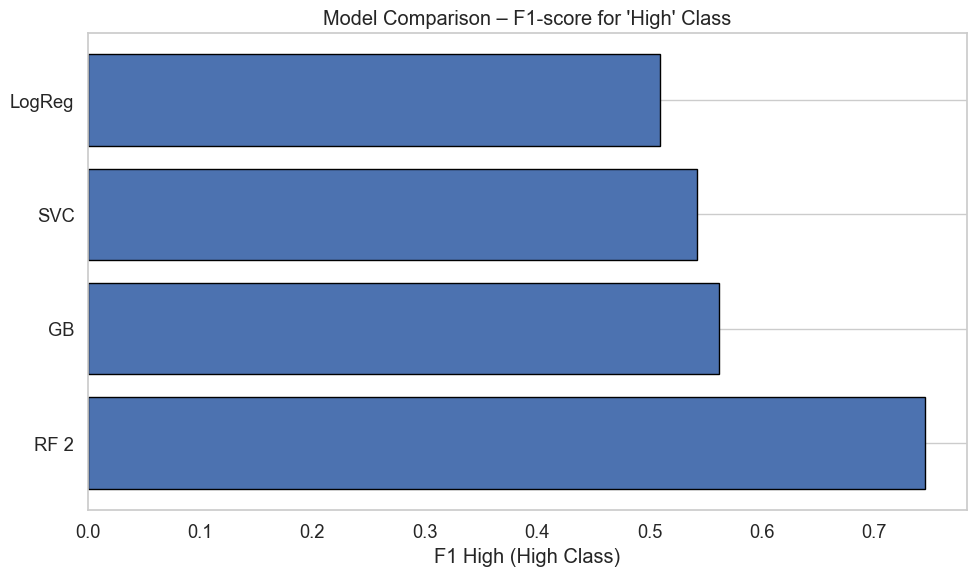

In [115]:
labels = list(evaluation_results.keys())
f1_scores = [evaluation_results[model]["F1 High"] for model in labels]

plt.figure(figsize=(10, 6))
plt.barh(labels, f1_scores, edgecolor="black")
plt.xlabel("F1 High (High Class)")
plt.title("Model Comparison – F1-score for 'High' Class")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()


### Summary - Binary Classification

Using the plot, it's clear that the tuned Random Forest algorithm performs the best in binary classification (at least comparing the F1 scores for each 'high' quality together).

Threshold 6 is the most balanced threshold to use.

Now, I'll move onto exploring regression.

### Regression

Now I've finished exploring binary classification, I'll try modelling using quality as a **continuous variable** by using **regression**, again only with the red wine dataset for now.

To begin, I'll again split my data frame into testing and training data:

In [116]:
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red, y_red, test_size=0.2, stratify=y_red_bin_6, random_state=42)

Then rescale:

In [117]:
X_train_red_scaled = scaler.fit_transform(X_train)
X_test_red_scaled = scaler.transform(X_test)

Now, to define my model. First I'll try again with a Random Forest model - this time, `Random Forest Regressor`. I won't fine tune any parameters just yet, either.

In [119]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_red_scaled, y_red_train)

RandomForestRegressor(random_state=42)

To define success for my regressor, I'll compare the:
- Mean squared error (MSE)
- Root MSE (RMSE)
- R2 score

So I'll import those from `sklearn`:

In [121]:
from sklearn.metrics import mean_squared_error, r2_score

Now I'll have a quick look at how it performs:

In [126]:
y_pred_rfr = rfr.predict(X_test_red_scaled)
mse = mean_squared_error(y_red_test, y_pred_rfr)
rmse = mse ** 0.5
r2 = r2_score(y_red_test, y_pred_rfr)
print(f"Random Forest Regressor\nMSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

Random Forest Regressor
MSE: 0.354 | RMSE: 0.595 | R2: 0.507


#### Random Forest Regressor

The Random Forest Regressor achieved the following performance on the red wine dataset:

- **MSE**: 0.354  
- **RMSE**: 0.595  
- **R²**: 0.507  

These results indicate the model can predict wine quality within approximately +-0.6 points on average. An R2 of 0.51 suggests the model explains just over half of the variance in quality scores — a strong baseline for this dataset, where subjective quality ratings and limited features naturally constrain model performance.


Now I'll try with another model - SVC:

In [133]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_red_scaled, y_red_train)

SVR()

And to look at the results:

In [135]:
y_pred_svr = svr.predict(X_test_red_scaled)
mse = mean_squared_error(y_red_test, y_pred_svr)
rmse = mse ** 0.5
r2 = r2_score(y_red_test, y_pred_svr)
print(f"SVR\nMSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

SVR
MSE: 0.411 | RMSE: 0.641 | R2: 0.428


### SVR

The Support Vector Regressor (SVR) produced the following results on the red wine dataset:

- **MSE**: 0.411  
- **RMSE**: 0.641  
- **R2**: 0.428  

While SVR does capture some of the underlying structure in the data, it underperforms compared to the base **Random Forest Regressor**, which achieved **RMSE = 0.595** and **R2 = 0.507**. 

This suggests that SVR may be less effective at modelling the non-linearities present in the wine quality features, especially without additional tuning.

Random Forest remains the stronger choice for this regression task so far.


Now another model, I'll try GBR:

In [136]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_red_scaled, y_red_train)

GradientBoostingRegressor(random_state=42)

And to look at results:

In [137]:
y_pred_gbr = gbr.predict(X_test_red_scaled)
mse = mean_squared_error(y_red_test, y_pred_gbr)
rmse = mse ** 0.5
r2 = r2_score(y_red_test, y_pred_gbr)
print(f"GBR\nMSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

GBR
MSE: 0.422 | RMSE: 0.649 | R2: 0.413


### GBR

The Gradient Boosting Regressor produced the following results:

- **MSE**: 0.422  
- **RMSE**: 0.649  
- **R²**: 0.413  

Compared to the **Random Forest Regressor** (RMSE = 0.595, R2 = 0.507), the GBR underperforms slightly in both prediction accuracy and explained variance.

As I did with Binary Classification, I'll try fine tuning the best forming model, Random Forest Regressor, to see if I can improve results.

This time, I'll use `RandomizedSearchCV` to find the best parameters for tuning.

In [142]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=parameters,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_red_scaled, y_red_train)
best_rfr = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


Now, using the parameters above, I'll reevaluate my Random Forest model:

In [ ]:
y_pred_best_rfr = best_rfr.predict(X_test_red_scaled)
mse = mean_squared_error(y_red_test, y_pred_best_rfr)
rmse = mse ** 0.5
r2 = r2_score(y_red_test, y_pred_best_rfr)

print(f"Param Tuned Random Forest\nRMSE: {rmse:.3f} | R²: {r2:.3f}")

Tuned Random Forest
RMSE: 0.586 | R²: 0.521


Exception ignored in: <function ResourceTracker.__del__ at 0x107e56de0>
Traceback (most recent call last):
  File "/usr/local/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/local/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/local/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10c7eede0>
Traceback (most recent call last):
  File "/usr/local/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/local/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/py

### Param Tuned Random Forest Regressor

After tuning with 10-fold cross-validation and `RandomizedSearchCV`, the best Random Forest configuration was:

```python
{
    'n_estimators': 200,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'log2',
    'max_depth': None
}
```

This model achieved:

- **RMSE**: 0.586  
- **R²**: 0.521  

This marks an improvement over the baseline Random Forest (RMSE = 0.595, R2 = 0.507), showing that even some parameter tuning can enhance predictive performance on this dataset.



### Task 3

During task 3, I completed:

Binary Classification: 
- Reduced wine quality to binary labels (quality > threshold).
- Tried multiple thresholds: 5, 6, and 7.
- Tested and briefly evaluated multiple models:
    - Random Forest
    - Logistic Regression
    - SVC
    - Gradient Boosting
- Used appropriate classification metrics:
    - F1-score
    - Precision and Recall
    - Accuracy
- Performed k-fold cross-validation (10-fold) and reported scores.
- Tuned the best model (Random Forest) and reported improvements.

Regression:
- Switched to treating quality as a continuous variable.
- Trained and evaluated:
    - Random Forest Regressor (baseline + tuned)
    - Support Vector Regressor (SVR)
    - Gradient Boosting Regressor (GBR)
- Used correct regression metrics:
    - RMSE
    - MSE
    - R2
- Tuned Random Forest for regression and observed performance gains.

## Task 4: Model Evaluation
___

### Model Evaluation

Task 4 was to evaluate the model using cross validation - I used 5 fold cross validation, which meant the model was trained on 80% of data and tested on 20%. 

The two different approaches I tried, as highlighted in Task 3, where:
1. **Binary classification**
2. **Regression**

The **metrics chosen** for my evaluation where:

*For BC* ->
   - **F1-score**
   - **AUC**
   - **ROC Curve**
*For R* ->
   - **NMSE**
   - **MSE**
   - **RMSE**
   - **MAE**
   - **R2**


### Binary Classification Review

To evaluate performance for BC, I plotted the two of the metrics suggested (**F1-score and AUC**) across the different binary classification thresholds tested (i.e. >5, >6, >7).

#### Metrics

- F1-score (Training): Measures the balance of precision and recall during training, averaged across 5-fold cross-validation.

- AUC (Testing): Shows model’s ability to separate the high vs low quality classes on the unseen test data, based on predicted probabilities.

The plot makes it easier to identify the best performing threshold and examine trade offs with each threshold. For example, what I didn't predict, that is shown, is a higher threshold (e.g. >7) gives higher AUC but a lower F1-score, showing the trade off between model confidence and balance.

#### Observations
- Threshold >6 achieves the best trade-off for both datasets, with high F1 and AUC scores — suggesting this threshold gives the most balanced classification.
- Red wine performs better at lower thresholds (e.g. >5) in terms of F1, likely due to fewer high-quality red wines making classification easier.
- White wine performs better at higher thresholds in terms of AUC, suggesting it distinguishes high-quality samples better despite more class imbalance.
- Threshold >7 leads to a sharp F1 drop, especially in red wine, due to the small number of samples labelled as "high quality", which reduces recall.

In [ ]:
x = range(3)
width = 0.2

plt.figure(figsize=(10, 6))

# Bars for Red Wine
plt.bar([i - 1.5*width for i in x], f1_scores_rw, width, label="Red F1", color="lightcoral")
plt.bar([i - 0.5*width for i in x], auc_scores_rw, width, label="Red AUC", color="indianred")

# Bars for White Wine
plt.bar([i + 0.5*width for i in x], f1_scores_ww, width, label="White F1", color="gold")
plt.bar([i + 1.5*width for i in x], auc_scores_ww, width, label="White AUC", color="orange")

plt.xticks(x, thresholds)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Binary Classification Review (Red vs White)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/bc_comparison.png")
plt.show()

### Regression Review

To compare how well the regression model performs during training vs on unseen test data, I visualised the most relevant error metrics using a grouped bar chart.

This chart evaluates the model's **generalisation ability** — whether it's just memorising the training data or actually learning to make accurate predictions (if there is overfitting).

#### Metrics shown:
- **MSE** (Mean Squared Error): For large errors (scaled/standardised)
- **RMSE** (Root Mean Squared Error): Also for large errors but for the original scale of the target variable
- **MAE** (Mean Absolute Error): Measures average error size

#### Observation:
- For both wine types, the training and test `MSE` and `RMSE` scores are quite close, suggesting the models generalise well.
- White wine has slightly higher test `MAE`, implying that while it learns well, it makes slightly more consistent errors on unseen samples than the red model.
- There is no strong evidence of overfitting — test performance is similar to training in all cases.
- The RMSE scores (`~0.14–0.15`) suggest the model is typically off by less than 1 quality point on average.

Training scores were obtained using **5-fold cross-validation**, and test scores come from the **unseen 20% test data**.

This comparison helps reveal signs of **overfitting** (if test errors are much higher than training) or **underfitting** (if both are high).

In [ ]:
train_mse_r = mse_r
train_rmse_r = rmse_r

test_mse_r = mean_squared_error(y_test_r, y_pred_reg_r)
test_rmse_r = np.sqrt(test_mse_r)
test_mae_r = mean_absolute_error(y_test_r, y_pred_reg_r)

train_mse_w = mse_w
train_rmse_w = rmse_w

test_mse_w = mean_squared_error(y_test_w, y_pred_reg_w)
test_rmse_w = np.sqrt(test_mse_w)
test_mae_w = mean_absolute_error(y_test_w, y_pred_reg_w)

metrics = ["MSE", "RMSE", "MAE"]
train_red = [train_mse_r, train_rmse_r, 0]
test_red = [test_mse_r, test_rmse_r, test_mae_r]

train_white = [train_mse_w, train_rmse_w, 0]
test_white = [test_mse_w, test_rmse_w, test_mae_w]

width = 0.2
plt.figure(figsize=(10, 6))

# red
plt.bar([i - 1.5 * width for i in x], train_red, width, label="Red Train", color="lightcoral")
plt.bar([i - 0.5 * width for i in x], test_red, width, label="Red Test", color="indianred")

# White
plt.bar([i + 0.5 * width for i in x], train_white, width, label="White Train", color="gold")
plt.bar([i + 1.5 * width for i in x], test_white, width, label="White Test", color="orange")

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Regression: Red vs White and Train vs Test")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/regression_error_comparison.png")
plt.show()

### End Task 4

In summary, to evaluate model performance, I used both **classification** and **regression** approaches and compared them using appropriate metrics.

### Binary Classification Evaluation

Binary classification models were trained using three thresholds for "high quality" (`>5`, `>6`, `>7`). Each model was evaluated using:
- **F1-score** (on training data via 5-fold cross-validation)
- **AUC** (on test set)
- **ROC Curve** (visual performance of true vs false identification of quality)

**Overall:**
- **Threshold >5** gives the highest F1-score, but performance is misleading due to **class imbalance** (very few *low quality* samples).
- **Threshold >6** provides the most balanced result, with both F1 and AUC scores being high.
- **Threshold >7** results in high AUC, but lower F1-score due to a small number of positive (high quality) samples, reducing amount of recall.

The bar chart comparing performance across thresholds shows that **threshold >6** is the best option overall.

### Regression Evaluation

I also used **Random Forest Regression** to predict the exact quality score as a continuous variable.

- Metrics used:
  - **MSE**, **RMSE**, **MAE** (on both training and test sets)
  - **5-fold cross-validation** for training scores
- A grouped bar chart to visualise training vs test errors

**Findings:**
- Training and test errors are close, indicating **good generalisation** with no major overfitting
- The regression model achieved a test **RMSE of `0.26`**, which is quite good
- **MAE** was low (`0.15`), meaning predictions are close to actual values on average.
- For both wine types, threshold >6 gave the best balance of performance across both F1 and AUC.
- Threshold >5 gave high F1-scores, but these are misleading due to class imbalance (most wines are above this score).
- Threshold >7 gave very high AUC in some cases, but the models struggled with F1-score due to the rarity of high-quality samples, especially in red wine.
- White wines generally showed higher AUC across all thresholds, suggesting they are easier to separate by quality in probability space.

---

### Conclusion

- **Binary classification** (threshold >6) offers clearer interpretability
- **Regression** gives more specific predictions but is harder to interpret
- Overall, both models performed well, with **no extreme overfitting** and good predictability


## Extensions

___

## Conclusion

___

## References

___

https://github.com/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb

https://github.com/PacktPublishing/Jupyter-Notebook-for-Data-Science

https://nbviewer.org/github/Tanu-N-Prabhu/Python/blob/master/Data_Cleaning/Data_Cleaning_using_Python_with_Pandas_Library.ipynb

https://www.markdownguide.org/cheat-sheet/

https://www.codecademy.com/resources/docs/markdown/tables

https://www.madeintext.com/bullet-point/

https://www.kaggle.com/code/devraai/vinho-verde-white-wine-quality-analysis/input

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
